# Hartmann 6D: analysis of 10 SMAC runs

This notebook loads all SMAC components with `master_utils.reload_components.load_smac_components` and compares incumbent performance across seeds.

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "master_utils").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from master_utils.reload_components import load_smac_components

RESULTS_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "hartmann"
    / "02_first_experiments"
    / "hartmann_6d_10seeds"
)
SEEDS = range(10)
HARTMANN_6D_MINIMUM = -3.322368011415515
CONFIDENCE = 0.95

plt.rcParams.update({"figure.figsize": (9, 5.5), "axes.grid": True})

## Load runs and construct incumbent trajectories

In [11]:
runs = {
    seed: load_smac_components(RESULTS_DIR / str(seed))
    for seed in SEEDS
}


def incumbent_trajectory(runhistory):
    trials = sorted(
        runhistory.items(),
        key=lambda item: item[1].starttime,
    )
    costs = np.asarray([value.cost for _, value in trials], dtype=float)
    return np.minimum.accumulate(costs)


trajectories = {
    seed: incumbent_trajectory(components["runhistory"])
    for seed, components in runs.items()
}
run_lengths = {seed: len(values) for seed, values in trajectories.items()}
assert min(run_lengths.values()) >= 500, run_lengths

n_trials = min(run_lengths.values())
trial_numbers = np.arange(1, n_trials + 1)
incumbent_costs = np.vstack([trajectories[seed][:n_trials] for seed in SEEDS])
run_lengths

{0: 500,
 1: 500,
 2: 500,
 3: 500,
 4: 500,
 5: 500,
 6: 500,
 7: 500,
 8: 500,
 9: 500}

In [12]:
def mean_and_ci(values, confidence=CONFIDENCE):
    values = np.asarray(values, dtype=float)
    mean = values.mean(axis=0)
    sem = values.std(axis=0, ddof=1) / np.sqrt(values.shape[0])
    critical_value = t.ppf((1 + confidence) / 2, df=values.shape[0] - 1)
    half_width = critical_value * sem
    return mean, mean - half_width, mean + half_width

## 1a. Final incumbent cost

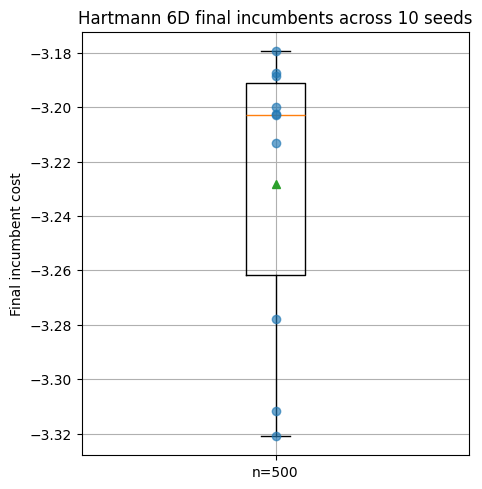

In [13]:
final_incumbent_costs = incumbent_costs[:, -1]

fig, ax = plt.subplots(figsize=(5, 5.5))
ax.boxplot(final_incumbent_costs, tick_labels=[f"n={n_trials}"], showmeans=True)
ax.scatter(np.ones(len(final_incumbent_costs)), final_incumbent_costs, alpha=0.65, zorder=3)
ax.set_ylabel("Final incumbent cost")
ax.set_title("Hartmann 6D final incumbents across 10 seeds")
plt.show()

## 1b. Incumbent cost after 200, 300, 400, and 500 trials

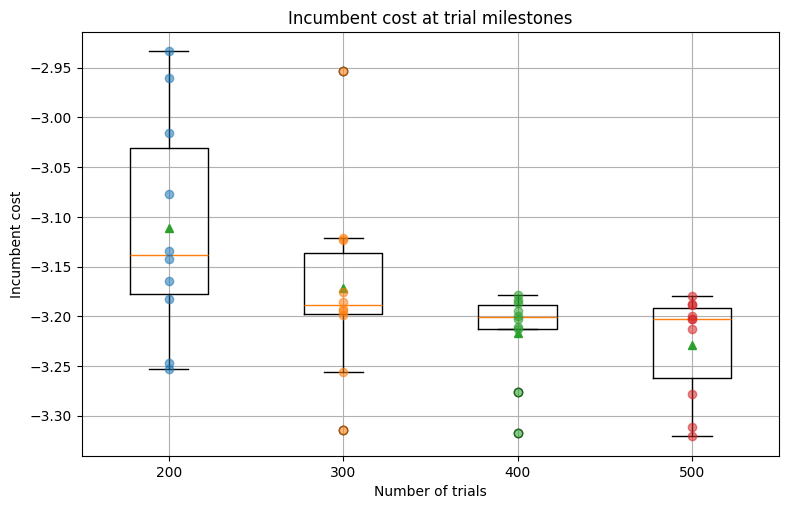

In [14]:
milestones = [200, 300, 400, 500]
milestone_costs = [incumbent_costs[:, n - 1] for n in milestones]

fig, ax = plt.subplots()
ax.boxplot(milestone_costs, tick_labels=milestones, showmeans=True)
for position, values in enumerate(milestone_costs, start=1):
    ax.scatter(np.full(len(values), position), values, alpha=0.55, zorder=3)
ax.set_xlabel("Number of trials")
ax.set_ylabel("Incumbent cost")
ax.set_title("Incumbent cost at trial milestones")
plt.show()

## 2. Mean best-so-far cost with 95% confidence interval

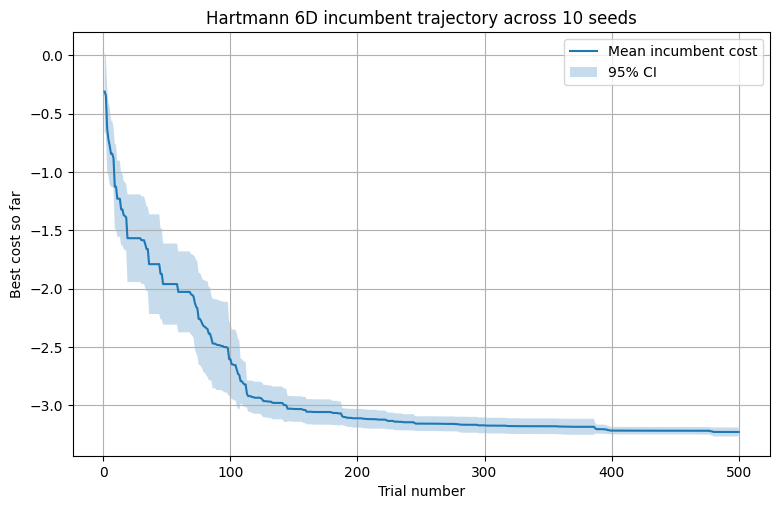

In [15]:
mean_cost, cost_ci_lower, cost_ci_upper = mean_and_ci(incumbent_costs)

fig, ax = plt.subplots()
ax.plot(trial_numbers, mean_cost, label="Mean incumbent cost")
ax.fill_between(
    trial_numbers,
    cost_ci_lower,
    cost_ci_upper,
    alpha=0.25,
    label="95% CI",
)
ax.set_xlabel("Trial number")
ax.set_ylabel("Best cost so far")
ax.set_title("Hartmann 6D incumbent trajectory across 10 seeds")
ax.legend()
plt.show()

## 3. Best-so-far cost for every run

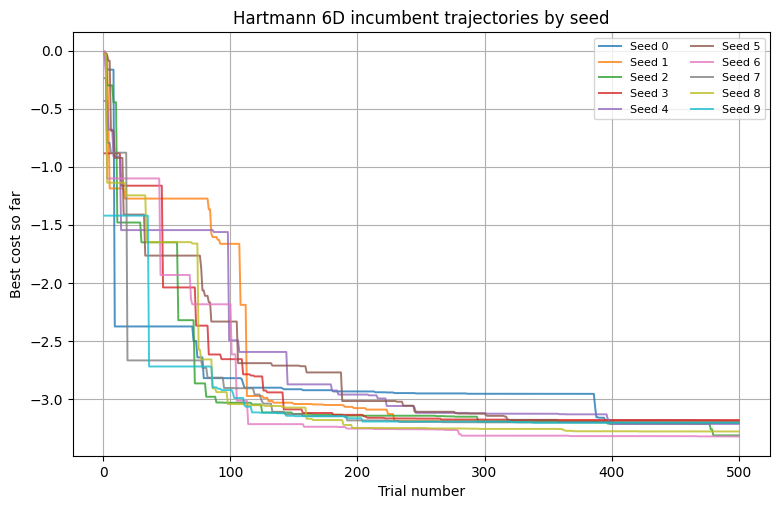

In [16]:
fig, ax = plt.subplots()
for seed, costs in zip(SEEDS, incumbent_costs):
    ax.plot(trial_numbers, costs, alpha=0.8, linewidth=1.4, label=f"Seed {seed}")
ax.set_xlabel("Trial number")
ax.set_ylabel("Best cost so far")
ax.set_title("Hartmann 6D incumbent trajectories by seed")
ax.legend(ncol=2, fontsize=8)
plt.show()

## 4. Simple regret on a logarithmic scale

Simple regret is $f(x_t^*) - f(x^*)$, using the known Hartmann-6 minimum $f(x^*) = -3.322368011415515$.

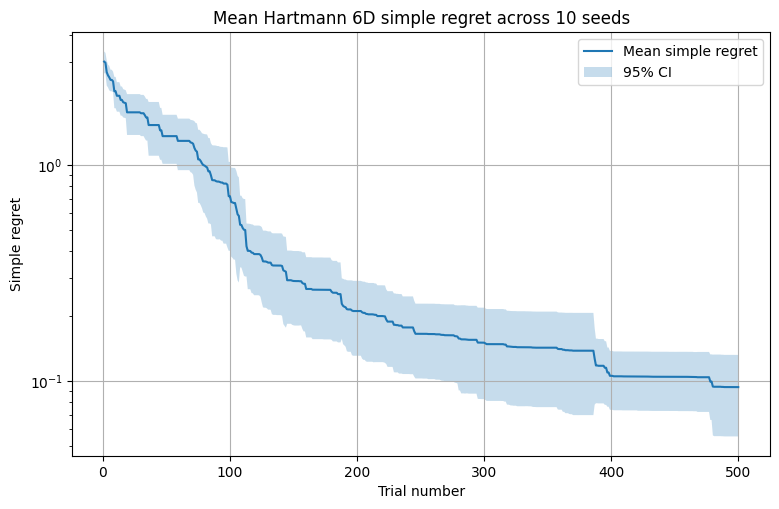

In [17]:
simple_regret = incumbent_costs - HARTMANN_6D_MINIMUM
mean_regret, regret_ci_lower, regret_ci_upper = mean_and_ci(simple_regret)
positive_floor = np.finfo(float).tiny

fig, ax = plt.subplots()
ax.plot(trial_numbers, mean_regret, label="Mean simple regret")
ax.fill_between(
    trial_numbers,
    np.maximum(regret_ci_lower, positive_floor),
    regret_ci_upper,
    alpha=0.25,
    label="95% CI",
)
ax.set_yscale("log")
ax.set_xlabel("Trial number")
ax.set_ylabel("Simple regret")
ax.set_title("Mean Hartmann 6D simple regret across 10 seeds")
ax.legend()
plt.show()

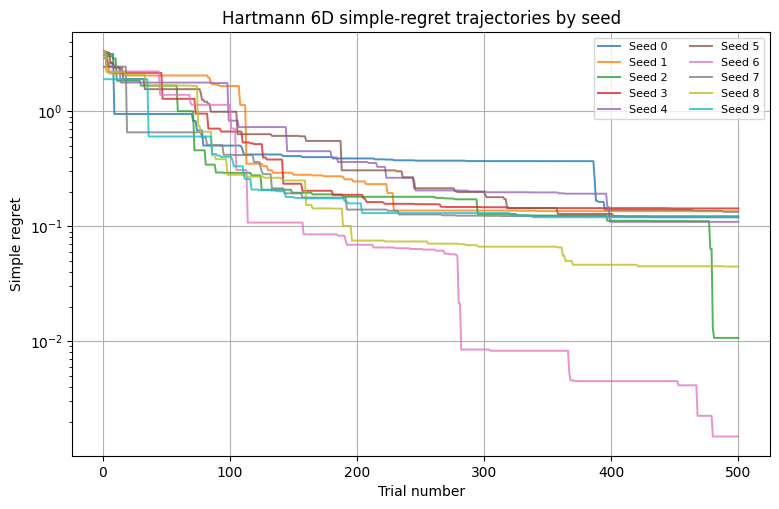

In [18]:
fig, ax = plt.subplots()
for seed, regrets in zip(SEEDS, simple_regret):
    ax.plot(trial_numbers, regrets, alpha=0.8, linewidth=1.4, label=f"Seed {seed}")
ax.set_yscale("log")
ax.set_xlabel("Trial number")
ax.set_ylabel("Simple regret")
ax.set_title("Hartmann 6D simple-regret trajectories by seed")
ax.legend(ncol=2, fontsize=8)
plt.show()

## 5. Final incumbent configuration and regret by seed

`simple_regret` reports regret on its original scale; `log10_simple_regret` reports its base-10 logarithm, matching the orders of magnitude shown on the logarithmic plots.

In [19]:
incumbent_rows = []
for seed, components in runs.items():
    incumbent = components["intensifier"].get_incumbent()
    incumbent_cost = components["runhistory"].get_cost(incumbent)
    regret = incumbent_cost - HARTMANN_6D_MINIMUM
    incumbent_rows.append(
        {
            "seed": seed,
            **dict(incumbent),
            "incumbent_cost": incumbent_cost,
            "simple_regret": regret,
            "log10_simple_regret": np.log10(max(regret, np.finfo(float).tiny)),
        }
    )

incumbent_summary = pd.DataFrame(incumbent_rows).sort_values("seed")
incumbent_summary.style.format(
    {
        **{f"x{i}": "{:.6f}" for i in range(1, 7)},
        "incumbent_cost": "{:.9f}",
        "simple_regret": "{:.9f}",
        "log10_simple_regret": "{:.4f}",
    }
)

,seed,x1,x2,x3,x4,x5,x6,incumbent_cost,simple_regret,log10_simple_regret
0,0,0.407226,0.889121,0.911085,0.581845,0.164827,0.023245,-3.188480547,0.133887465,-0.8733
1,1,0.404686,0.881448,0.846905,0.574143,0.143787,0.019652,-3.187291086,0.135076925,-0.8694
2,2,0.202973,0.127334,0.468643,0.283430,0.318631,0.656806,-3.311675281,0.010692730,-1.9709
3,3,0.199098,0.039125,0.471288,0.274630,0.300416,0.660470,-3.179389935,0.142978076,-0.8447
4,4,0.187890,0.059048,0.470454,0.254197,0.317159,0.657205,-3.213124976,0.109243035,-0.9616
5,5,0.404479,0.883834,0.850943,0.573639,0.122631,0.036343,-3.202824110,0.119543902,-0.9225
6,6,0.200460,0.146602,0.481556,0.274304,0.316222,0.654885,-3.320883345,0.001484667,-2.8284
7,7,0.403970,0.882242,0.994289,0.573779,0.134572,0.038244,-3.199835686,0.122532325,-0.9117
8,8,0.205725,0.089429,0.476365,0.267426,0.316667,0.655291,-3.277710651,0.044657360,-1.3501
9,9,0.404256,0.883652,0.898772,0.573276,0.129692,0.038500,-3.202673887,0.119694124,-0.9219


In [1]:
from smac import HyperparameterOptimizationFacade as HPOFacade
HPOFacade.get_model()

TypeError: get_model() missing 1 required positional argument: 'scenario'